# Data Inspection and Cleaning of Shooting Offenders Dataset

- Suspected perpetrator (if known) of a shooting incident
- This is an interesting dataset but will focus on shooting occurances 


In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
offenders = "../data/Shooting_Offenders_(2006-Present)_20260702.csv"
df_offenders = pd.read_csv(offenders)
df_offenders.head()

,INCIDENT_KEY,PERP_ID,PERP_AGE_GROUP,PERP_SEX,PERP_RACE
0,288208647,288208647-1,25-44,MALE,ASIAN / PACIFIC ISLANDER
1,73517103,73517103-18843,25-44,MALE,ASIAN / PACIFIC ISLANDER
2,193462348,193462348-1,25-44,MALE,ASIAN / PACIFIC ISLANDER
3,186606271,186606271-1,18-24,MALE,ASIAN / PACIFIC ISLANDER
4,168757750,168757750-26618,25-44,MALE,ASIAN / PACIFIC ISLANDER


In [3]:
df_offenders.info()

<class 'pandas.DataFrame'>
RangeIndex: 18901 entries, 0 to 18900
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   INCIDENT_KEY    18901 non-null  int64
 1   PERP_ID         18901 non-null  str  
 2   PERP_AGE_GROUP  18871 non-null  str  
 3   PERP_SEX        18901 non-null  str  
 4   PERP_RACE       18901 non-null  str  
dtypes: int64(1), str(4)
memory usage: 738.4 KB


In [4]:
df_offenders.isna().sum()

INCIDENT_KEY       0
PERP_ID            0
PERP_AGE_GROUP    30
PERP_SEX           0
PERP_RACE          0
dtype: int64

- Seems like there is very little missing data, but some may be "UNKNOWN"

## Duplicates?

In [6]:
print(f"Number of duplicated rows in df_shootings: {df_offenders.duplicated().sum()}")

Number of duplicated rows in df_shootings: 0


In [8]:
#There may be multiple offenders per shooting incident
print(f"Number of duplicate INCIDENT_KEY values in df_offenders: {df_offenders["INCIDENT_KEY"].duplicated().sum()}")

      
#But, PERP_ID should be unique (zero) in df_offenders
print(f"Number of duplicate PERP_ID's in df_offenders: {df_offenders["PERP_ID"].duplicated().sum()}")

Number of duplicate INCIDENT_KEY values in df_offenders: 4183
Number of duplicate PERP_ID's in df_offenders: 0


## Quick EDA of Age group, Sex, and Race

In [26]:
ages = df_offenders["PERP_AGE_GROUP"].value_counts(normalize=True)
display(ages)

PERP_AGE_GROUP
18-24      0.358805
25-44      0.326745
UNKNOWN    0.178263
<18        0.096126
45-64      0.036564
65+        0.003179
1020       0.000053
1028       0.000053
2021       0.000053
940        0.000053
224        0.000053
1822       0.000053
Name: proportion, dtype: float64

In [27]:
df_offenders["PERP_AGE_GROUP"].unique()

<StringArray>
[  '25-44',   '18-24',     '<18',   '45-64', 'UNKNOWN',     '65+',    '1020',
    '1028',    '2021',     '940',     '224',    '1822',       nan]
Length: 13, dtype: str

<Axes: xlabel='PERP_AGE_GROUP'>

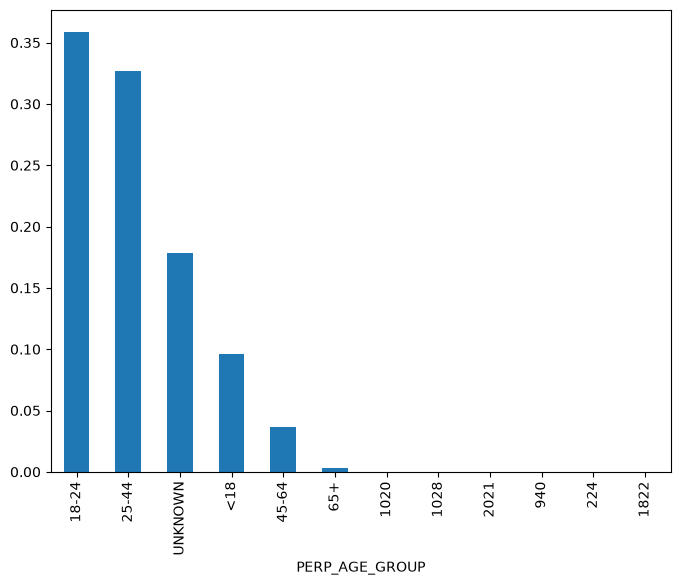

In [28]:
plt.figure(figsize=(8,6))
ages.plot(kind='bar')

- There is some indication that nost offenders are young but there is also erroneous data entries and a large proportion of unknown ages here too.
- This data is too messy

In [29]:
df_offenders["PERP_SEX"].unique()

<StringArray>
['MALE', 'FEMALE', 'UNKNOWN']
Length: 3, dtype: str

In [30]:
sex = df_offenders["PERP_SEX"].value_counts(normalize=True)
display(sex)

PERP_SEX
MALE       0.902122
UNKNOWN    0.073806
FEMALE     0.024073
Name: proportion, dtype: float64

<Axes: xlabel='PERP_SEX'>

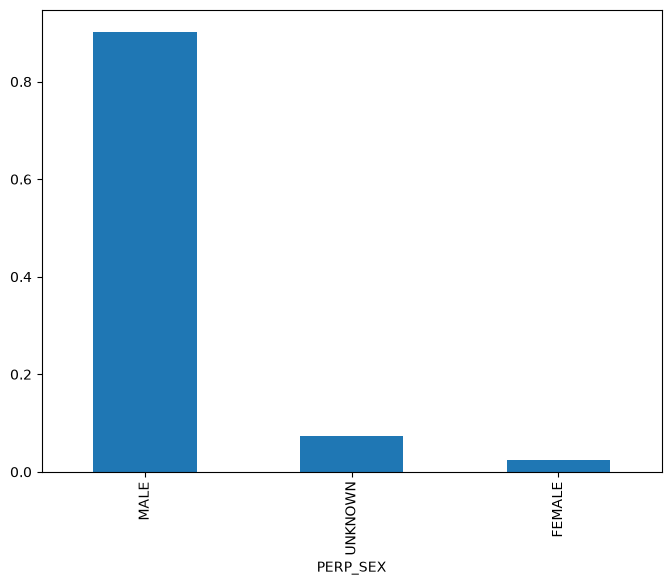

In [31]:
plt.figure(figsize=(8,6))
sex.plot(kind='bar')

In [32]:
df_offenders["PERP_RACE"].unique()

<StringArray>
[      'ASIAN / PACIFIC ISLANDER',                          'BLACK',
 'AMERICAN INDIAN/ALASKAN NATIVE',                 'BLACK HISPANIC',
                 'WHITE HISPANIC',                          'WHITE',
                        'UNKNOWN']
Length: 7, dtype: str

In [33]:
race = df_offenders["PERP_RACE"].value_counts(normalize=True)
display(race)

PERP_RACE
BLACK                             0.670758
WHITE HISPANIC                    0.136289
UNKNOWN                           0.092535
BLACK HISPANIC                    0.076028
WHITE                             0.015237
ASIAN / PACIFIC ISLANDER          0.009047
AMERICAN INDIAN/ALASKAN NATIVE    0.000106
Name: proportion, dtype: float64

<Axes: xlabel='PERP_RACE'>

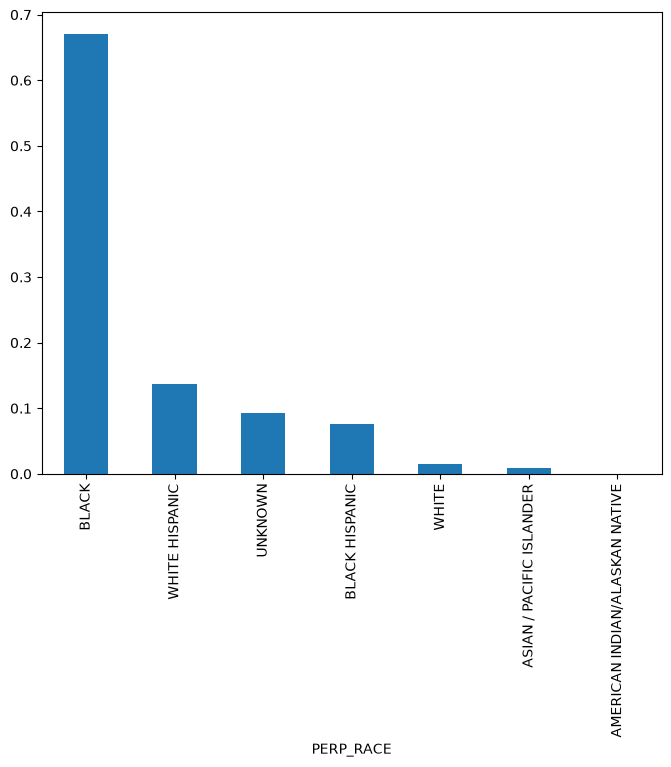

In [34]:
plt.figure(figsize=(8,6))
race.plot(kind='bar')